# 08 · The prediction API and model monitoring

**Use case.** The verified-purchase model (04) goes into an application: score a review the app just received (inductive — from its columns and its neighbours), score in batches, and watch the model's inputs drift.

**What you will learn**
1. Read the model's feature schema — what a request must carry
2. Inductive prediction: a row the platform has never stored, with `related_entities`
3. Batch prediction, and the `active:<project>` selector
4. Monitoring: feature health as a table and a chart, thresholds, alert configuration (email / webhook)
5. Recent-prediction monitoring for the model

**What this costs.** no training; 50 credits per prediction (batch items included).

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "verified", kind="data_science")
model = next(m for m in project_models(p) if m.get("metrics") and m.get("is_active"))
print("model:", model["label"], "· AUROC", round(model["metrics"]["auroc"], 3))

reusing project 28106708-9ec0-48e4-b292-d600b9bc2ed8 (amazon-reviews-verified, status=ready)
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


model: v1 · Baseline · active · AUROC 0.628


In [3]:
schema = ls.predict.model(model["model_id"])
print("task:", schema.get("task_type"), "· entity:", schema.get("entity_table"), schema.get("entity_col"), "· target:", schema.get("target_col"))
print("required features:", [f.get("name") if isinstance(f, dict) else f for f in (schema.get("required_features") or [])])
print("optional features:", [f.get("name") if isinstance(f, dict) else f for f in (schema.get("optional_features") or [])])
print("active selector  :", schema.get("active_selector"))

task: binary_classification · entity: review __row_id__ · target: verified
required features: ['rating', 'review_text', 'summary']
optional features: []
active selector  : active:28106708-9ec0-48e4-b292-d600b9bc2ed8


## Inductive: a review the platform has never stored

A relational model predicts from a neighbourhood, so a brand-new row needs its neighbours: pass the review's own columns plus `related_entities` — the ids of the product and customer it links to (they must exist). Without them the API refuses with a message that says exactly that.

In [4]:
review = p.table("review").to_pandas()
sample = review.iloc[0]
features = {"review_text": "Arrived on time, exactly as described. The kids loved it and we read it twice the first night.", "summary": "Great buy", "rating": 5}
out = ls.predict.predict(model_id=model["model_id"], mode="inductive", features=features,
                         related_entities={"product": int(sample["product_id"]), "customer": int(sample["customer_id"])})
print("verified?", out["result"]["prediction"], "· probability", round(out["result"].get("probability") or 0, 3), "· mode", out["mode"])
if out.get("warnings"): print("warnings:", out["warnings"])

verified? 1 · probability 0.909 · mode inductive


In [5]:
from langsat import errors
try:
    ls.predict.predict(model_id=model["model_id"], mode="inductive", features=features)     # no neighbours → refused, clearly
except errors.LangsatError as e:
    print(type(e).__name__, "·", str(e.message)[:220])

Invalid · This is a relational model: its predictions come from message passing over related rows, and none were supplied. Pass `related_entities` (ids of rows that already exist) or `related_data` (the new rows themselves) for th


Batch scoring with the **active** selector — `model_id="active:<project_id>"` always resolves to the version the project serves, so a deploy of v2 needs no client change.

In [6]:
top = ls.predict.top(model["model_id"], n=5)
ids = [r["entity_id"] for r in top["ranking"]]
batch = ls.predict.predict_batch(model_id=f"active:{p.id}", entity_ids=ids)
print(batch["succeeded"], "scored via active selector;", [round(pr.get("probability") or 0, 3) for pr in batch["predictions"]])

5 scored via active selector; [0.922, 0.921, 0.92, 0.919, 0.919]


## Monitoring

Every prediction is logged with its inputs. `monitoring.summary()` compares recent inputs to the training baseline per feature (null rate, drift, new categories …); thresholds turn that into warning / critical, and the alert configuration sends an email or signs a webhook.

In [7]:
summary = p.monitoring.summary()
feat = pd.DataFrame(summary.get("features") or [])
cols = [c for c in ("feature_name", "dtype", "health", "request_count", "missing_rate", "drift_score") if c in feat.columns]
print("state:", summary.get("state"), "· predictions in window:", summary.get("total_predictions"), "· alerts:", summary.get("total_alerts"))
feat[cols] if len(feat) else summary

state: ready · predictions in window: 70 · alerts: 0


,feature_name,dtype,health,request_count,drift_score
0,summary,text,insufficient_data,70,0.81
1,review_text,text,insufficient_data,70,0.48
2,rating,categorical,insufficient_data,70,NaN
3,customer.customer_name,categorical,insufficient_data,0,NaN
4,product.description,text,insufficient_data,0,NaN
5,product.title,text,insufficient_data,0,NaN
6,product.brand,categorical,insufficient_data,0,NaN
7,product.category,categorical,insufficient_data,0,NaN
8,product.price,numerical,insufficient_data,0,NaN


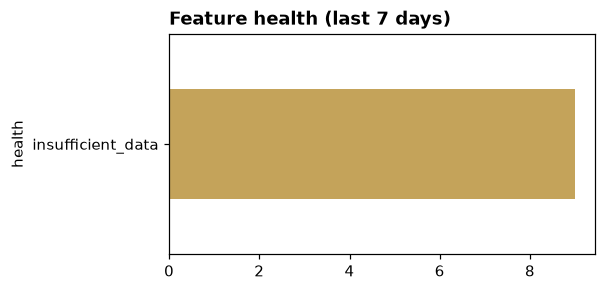

In [8]:
import matplotlib.pyplot as plt
counts = feat["health"].value_counts() if len(feat) else pd.Series(dtype=int)
f, ax = plt.subplots(figsize=(5, 2.6)); counts.plot(kind="barh", ax=ax, color="#c4a35a"); ax.set_title("Feature health (last 7 days)", loc="left", fontweight="bold"); fig(f)

In [9]:
th = p.monitoring.thresholds()
print("effective thresholds:", {k: v for k, v in (th.get("effective") or {}).items() if k in ("null_rate_warning", "drift_warning", "new_category_warning")})
print("alerts:", {k: v for k, v in p.monitoring.alerts_config().items() if k in ("email_alerts_enabled", "webhook_enabled", "min_severity", "min_alert_interval_hours")})
recent = ls.predict.monitoring(model["model_id"], days=7)
print("recent:", {k: recent.get(k) for k in ("state", "total_predictions", "features_warning", "features_critical", "anomaly_score")})

effective thresholds: {'null_rate_warning': 0.1, 'drift_warning': 1.0, 'new_category_warning': 0.1}


alerts: {'email_alerts_enabled': False, 'webhook_enabled': False, 'min_alert_interval_hours': 24, 'min_severity': 'warning'}
recent: {'state': 'ready', 'total_predictions': 70, 'features_warning': 0, 'features_critical': 0, 'anomaly_score': 1.41}


In [10]:
save_metrics(".", {"notebook": "08_predict_api_and_monitoring", "task": "serve + monitor the binary model from 04", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"],
                   "headline": {"inductive_probability": round(out["result"].get("probability") or 0, 4), "batch_scored": batch["succeeded"],
                                "monitored_features": int(len(feat)), "predictions_in_window": summary.get("total_predictions")}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [09 · Webhooks](../09_webhooks/) — be told when a job finishes (and wire the alert webhook the same way)
- The SDK docs page for the API contract: https://langsat.ai/sdk/langsat-v1.json